In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# 2 多层感知机

## 2.1 理论计算题

### 1. 非线性激活函数的重要性

一个单隐藏层 MLP，隐藏层无激活函数：
h = W1 x + b1,   o = W2 h + b2。
代入得 o = W2 (W1 x + b1) + b2 = (W2 W1) x + (W2 b1 + b2)。
记 W' = W2 W1, b' = W2 b1 + b2，则 o = W' x + b'，仍为线性模型。因此非线性激活函数是 MLP 表达非线性的必要条件。

### 2. Sigmoid 与 tanh 的表达式及导数

- Sigmoid：σ(x) = 1/(1+e^{-x})，导数 σ'(x) = σ(x)(1-σ(x))。
- tanh：tanh(x) = (e^x - e^{-x})/(e^x + e^{-x})，导数 tanh'(x) = 1 - tanh^2(x)。

两个导数都能用自身表示，但饱和区间导数趋近 0，易造成梯度消失。

In [2]:
batch_size = 128
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(f"训练样本数: {len(train_dataset)}, 测试样本数: {len(test_dataset)}")

训练样本数: 60000, 测试样本数: 10000


In [3]:
input_size = 28 * 28
hidden_size = 128   # 修改隐藏层维度
output_size = 10

W1 = torch.normal(0, 0.02, size=(input_size, hidden_size), device=device, requires_grad=True)
b1 = torch.zeros(hidden_size, device=device, requires_grad=True)
W2 = torch.normal(0, 0.02, size=(hidden_size, output_size), device=device, requires_grad=True)
b2 = torch.zeros(output_size, device=device, requires_grad=True)
params = [W1, b1, W2, b2]
print(f"W1: {W1.shape}, W2: {W2.shape}")

W1: torch.Size([784, 128]), W2: torch.Size([128, 10])


In [4]:
def relu(x):
    return torch.clamp(x, min=0)

def forward(x):
    x = x.view(-1, input_size)
    h = relu(x @ W1 + b1)
    return h @ W2 + b2

def cross_entropy_with_softmax(logits, y):
    # 数值稳定 softmax + 交叉熵
    logits_max = logits.max(dim=1, keepdim=True)[0]
    logits_shift = logits - logits_max
    exp_logits = torch.exp(logits_shift)
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    return -torch.log(probs[range(len(y)), y] + 1e-8).mean()

def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

def evaluate(loader):
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = forward(X)
            loss = cross_entropy_with_softmax(logits, y)
            n = y.size(0)
            total_loss += loss.item() * n
            total_acc += accuracy(logits, y) * n
            total_n += n
    return total_loss / total_n, total_acc / total_n

def sgd_update(params, lr):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p.grad.zero_()

In [5]:
epochs = 12
learning_rate = 0.05
for epoch in range(epochs):
    train_loss, train_acc, num_samples = 0.0, 0.0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        logits = forward(X)
        loss = cross_entropy_with_softmax(logits, y)
        loss.backward()
        sgd_update(params, learning_rate)
        n = y.size(0)
        train_loss += loss.item() * n
        train_acc += accuracy(logits, y) * n
        num_samples += n
    test_loss, test_acc = evaluate(test_loader)
    print(f"Epoch {epoch+1:2d}: train loss={train_loss/num_samples:.4f}, train acc={train_acc/num_samples:.4f} | "
          f"test loss={test_loss:.4f}, test acc={test_acc:.4f}")

Epoch  1: train loss=0.9756, train acc=0.6812 | test loss=0.6608, test acc=0.7634
Epoch  2: train loss=0.5709, train acc=0.8036 | test loss=0.5551, test acc=0.8057
Epoch  3: train loss=0.5020, train acc=0.8266 | test loss=0.5470, test acc=0.7952
Epoch  4: train loss=0.4714, train acc=0.8360 | test loss=0.4841, test acc=0.8287
Epoch  5: train loss=0.4515, train acc=0.8416 | test loss=0.4718, test acc=0.8312
Epoch  6: train loss=0.4334, train acc=0.8483 | test loss=0.4517, test acc=0.8390
Epoch  7: train loss=0.4199, train acc=0.8531 | test loss=0.4449, test acc=0.8435
Epoch  8: train loss=0.4076, train acc=0.8580 | test loss=0.4424, test acc=0.8431
Epoch  9: train loss=0.3966, train acc=0.8621 | test loss=0.4631, test acc=0.8314
Epoch 10: train loss=0.3879, train acc=0.8641 | test loss=0.4249, test acc=0.8489
Epoch 11: train loss=0.3792, train acc=0.8674 | test loss=0.4158, test acc=0.8521
Epoch 12: train loss=0.3713, train acc=0.8702 | test loss=0.4098, test acc=0.8533


# 3 模型选择、权重衰减和丢弃法

## 3.1 理论计算题

### 1. 过拟合与欠拟合

训练误差：模型在训练集上的平均损失，反映模型对已知数据的拟合能力。泛化误差：模型在未知测试集上的损失，代表真实预测能力。

当训练误差极低但泛化误差很高时，模型处于过拟合状态。缓解方法：
- 降低模型复杂度（减少层数或神经元数）
- 引入正则化（L2 权重衰减、Dropout）
- 早停、数据增强、增加训练数据

### 2. K 折交叉验证

步骤：
1. 将数据集随机划分成 K 个互斥子集（尽量等大）。
2. 对于每个子集 i：以该子集为验证集，其余 K-1 个子集为训练集，训练模型并计算验证误差。
3. 计算 K 次验证误差的平均值作为该超参数配置的性能。
4. 选择平均验证误差最低的模型，最后用全部数据重新训练。

In [6]:
def dropout_layer(x, prob):
    assert 0 <= prob <= 1
    if prob == 0:
        return x
    if prob == 1:
        return torch.zeros_like(x)
    mask = (torch.rand_like(x) > prob).float()
    return mask * x / (1.0 - prob)

In [7]:
torch.manual_seed(SEED)
num_train, num_val, max_deg = 40, 120, 15

def generate_data(n):
    x = torch.linspace(-2.5, 2.5, n).reshape(-1, 1)
    y = 0.5 + 1.2*x - 0.5*x**2 + 0.2*torch.randn_like(x)
    return x, y

x_train, y_train = generate_data(num_train)
x_val, y_val = generate_data(num_val)

# 构造多项式特征（带阶乘归一化）
powers = torch.arange(1, max_deg+1).float().view(1, -1)
X_train_poly = (x_train ** powers) / torch.exp(torch.lgamma(powers + 1))
X_val_poly = (x_val ** powers) / torch.exp(torch.lgamma(powers + 1))
X_train_poly = X_train_poly.to(device)
X_val_poly = X_val_poly.to(device)
y_train, y_val = y_train.to(device), y_val.to(device)
print(f"多项式特征维度: {X_train_poly.shape[1]}")

多项式特征维度: 15


In [8]:
def mse_loss(pred, target):
    return ((pred - target) ** 2).mean()

def train_poly(mode="none", wd=0.0, dp=0.0, epochs=200, lr=0.02):
    torch.manual_seed(SEED)
    W = torch.normal(0, 0.02, size=(max_deg, 1), device=device, requires_grad=True)
    b = torch.zeros(1, device=device, requires_grad=True)
    train_losses, val_losses = [], []
    for ep in range(epochs):
        features = X_train_poly
        if mode == "dropout":
            features = dropout_layer(features, dp)
        pred = features @ W + b
        loss = mse_loss(pred, y_train)
        loss.backward()
        with torch.no_grad():
            if mode == "weight_decay":
                W *= (1 - lr * wd)   # 权重衰减
            W -= lr * W.grad
            b -= lr * b.grad
            W.grad.zero_()
            b.grad.zero_()
        with torch.no_grad():
            train_losses.append(mse_loss(X_train_poly @ W + b, y_train).item())
            val_losses.append(mse_loss(X_val_poly @ W + b, y_val).item())
    print(f"{mode:>12s}: final train loss = {train_losses[-1]:.4f}, final val loss = {val_losses[-1]:.4f}")
    return train_losses, val_losses

loss_none = train_poly("none")
loss_wd = train_poly("weight_decay", wd=1.0)   # 使用不同的衰减系数
loss_drop = train_poly("dropout", dp=0.3)      # 使用不同的 dropout 概率

        none: final train loss = 0.0495, final val loss = 0.0521
weight_decay: final train loss = 0.2447, final val loss = 0.1727
     dropout: final train loss = 0.3962, final val loss = 0.3072


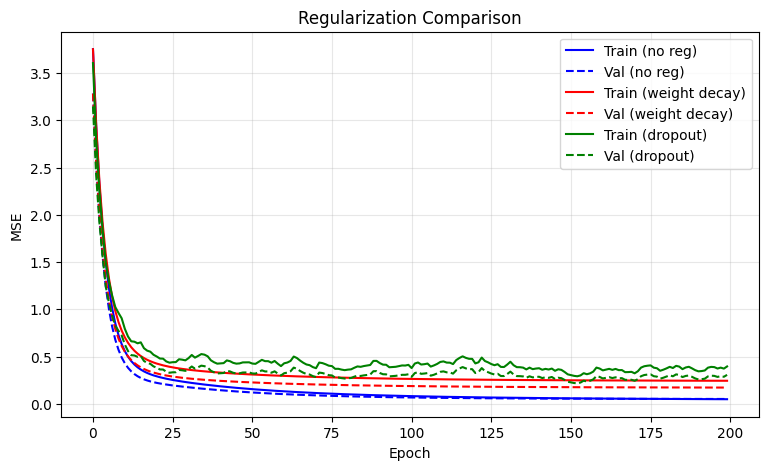

In [9]:
plt.figure(figsize=(9,5))
plt.plot(loss_none[0], 'b-', label='Train (no reg)')
plt.plot(loss_none[1], 'b--', label='Val (no reg)')
plt.plot(loss_wd[0], 'r-', label='Train (weight decay)')
plt.plot(loss_wd[1], 'r--', label='Val (weight decay)')
plt.plot(loss_drop[0], 'g-', label='Train (dropout)')
plt.plot(loss_drop[1], 'g--', label='Val (dropout)')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Regularization Comparison')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# 4 数值稳定性和激活函数

## 4.1 理论计算题

深层网络中梯度包含连乘项 ∏_{i=t}^{d-1} (∂h^{i+1}/∂h^i)，而 ∂h^{i+1}/∂h^i = D_i W_i（D_i 为激活函数导数对角阵）。

- 梯度爆炸：当多数 ||D_i|| ||W_i|| > 1，连乘指数增长。
- 梯度消失：当多数 ||D_i|| ||W_i|| < 1，连乘指数衰减。

Sigmoid 的最大导数为 0.25，且饱和时趋近 0，易导致消失。ReLU 在正区导数为 1，不饱和，因此显著缓解梯度消失。

In [10]:
def build_deep_net(activation='sigmoid', width=128, depth=15, in_dim=128, out_dim=1):
    layers = []
    dim = in_dim
    for _ in range(depth):
        layers.append(nn.Linear(dim, width))
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        else:
            layers.append(nn.ReLU())
        dim = width
    layers.append(nn.Linear(width, out_dim))
    return nn.Sequential(*layers).to(device)

def init_normal(model, std=0.5):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0, std=std)
            nn.init.zeros_(m.bias)

def init_xavier(model):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

def show_grad_norms(model, title, top_k=4):
    norms = []
    for name, p in model.named_parameters():
        if 'weight' in name and p.grad is not None:
            norms.append((name, p.grad.norm().item()))
    print(f"\n{title}")
    print("前几层:", [f"{n}:{v:.2e}" for n,v in norms[:top_k]])
    print("后几层:", [f"{n}:{v:.2e}" for n,v in norms[-top_k:]])
    has_nan = any(torch.isnan(p.grad).any() for p in model.parameters() if p.grad is not None)
    print(f"存在NaN: {has_nan}")

def backward_once(model, title):
    x = torch.randn(32, 128, device=device)
    y = torch.randn(32, 1, device=device)
    model.zero_grad()
    out = model(x)
    loss = ((out - y)**2).mean()
    loss.backward()
    print(f"loss: {loss.item():.4f}")
    show_grad_norms(model, title)

In [11]:
net_sigmoid = build_deep_net('sigmoid', width=128, depth=15)
init_normal(net_sigmoid, std=0.5)
backward_once(net_sigmoid, "Sigmoid + Normal(0,0.5)")

net_relu_big = build_deep_net('relu', width=128, depth=15)
init_normal(net_relu_big, std=5.0)
backward_once(net_relu_big, "ReLU + Normal(0,5.0)")

net_xavier = build_deep_net('relu', width=128, depth=15)
init_xavier(net_xavier)
backward_once(net_xavier, "ReLU + Xavier")

loss: 13.5228

Sigmoid + Normal(0,0.5)
前几层: ['0.weight:1.03e-01', '2.weight:2.74e-01', '4.weight:5.84e-01', '6.weight:8.92e-01']
后几层: ['24.weight:1.45e+01', '26.weight:2.50e+01', '28.weight:3.62e+01', '30.weight:5.19e+01']
存在NaN: False
loss: inf

ReLU + Normal(0,5.0)
前几层: ['0.weight:nan', '2.weight:nan', '4.weight:nan', '6.weight:nan']
后几层: ['24.weight:nan', '26.weight:nan', '28.weight:inf', '30.weight:inf']
存在NaN: True
loss: 1.3039

ReLU + Xavier
前几层: ['0.weight:2.83e-02', '2.weight:2.80e-02', '4.weight:2.88e-02', '6.weight:2.46e-02']
后几层: ['24.weight:1.67e-02', '26.weight:1.65e-02', '28.weight:1.14e-02', '30.weight:1.02e-02']
存在NaN: False


# 5 泛化表现、协变量偏移和对抗性数据

## 5.1 理论计算题

协变量偏移：p(x) ≠ q(x) 但 p(y|x)=q(y|x)。例如：训练集图片来自白天的街景，测试集来自夜晚的街景（光照分布变化），但同一个物体对应的标签不变。

标签偏移：p(y) ≠ q(y) 但 p(x|y)=q(x|y)。例如：医院训练数据中患病率 30%，而真实人群患病率 5%；但患病或健康人群的症状分布相同。

区别：协变量偏移是输入的边缘分布变化，标签偏移是输出的边缘分布变化。修正方法不同：前者常用重要性加权 q(x)/p(x)，后者需估计 q(y)/p(y) 并重加权。

In [12]:
np.random.seed(SEED)
n_train, n_test = 800, 400
x_train = np.random.normal(-1.0, 1.0, (n_train, 1))
x_test = np.random.normal(2.0, 1.0, (n_test, 1))
y_train = 1.8 * x_train + np.random.normal(0, 0.2, (n_train, 1))
y_test = 1.8 * x_test + np.random.normal(0, 0.2, (n_test, 1))
print(f"训练x均值: {x_train.mean():.3f}, 测试x均值: {x_test.mean():.3f}")

def add_intercept(x):
    return np.concatenate([np.ones((x.shape[0], 1)), x], axis=1)

def ols(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def wls(X, y, w):
    W_mat = np.diag(w.ravel())
    return np.linalg.pinv(X.T @ W_mat @ X) @ X.T @ W_mat @ y

X_train_lr = add_intercept(x_train)
X_test_lr = add_intercept(x_test)
beta_ols = ols(X_train_lr, y_train)
y_pred_ols = X_test_lr @ beta_ols
mse_ols = np.mean((y_pred_ols - y_test)**2)
print(f"OLS 参数: {beta_ols.ravel()}")
print(f"校正前 MSE: {mse_ols:.4f}")

训练x均值: -1.046, 测试x均值: 2.083
OLS 参数: [0.00826788 1.80644859]
校正前 MSE: 0.0405


In [13]:
X_domain = np.vstack([x_train, x_test]).astype(np.float32)
y_domain = np.vstack([np.zeros((n_train,1)), np.ones((n_test,1))]).astype(np.float32)
X_domain_t = torch.tensor(X_domain, device=device)
y_domain_t = torch.tensor(y_domain, device=device)

w_d = torch.zeros((1,1), device=device, requires_grad=True)
b_d = torch.zeros(1, device=device, requires_grad=True)
optimizer = torch.optim.SGD([w_d, b_d], lr=0.05)

for epoch in range(800):
    logits = X_domain_t @ w_d + b_d
    prob = torch.sigmoid(logits)
    loss = -(y_domain_t * torch.log(prob+1e-8) + (1-y_domain_t) * torch.log(1-prob+1e-8)).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch+1) % 200 == 0:
        acc = ((prob > 0.5).float() == y_domain_t).float().mean().item()
        print(f"Epoch {epoch+1}: loss={loss.item():.4f}, acc={acc:.4f}")

with torch.no_grad():
    x_train_t = torch.tensor(x_train.astype(np.float32), device=device)
    p_test = torch.sigmoid(x_train_t @ w_d + b_d).cpu().numpy().ravel()
    p_train = 1 - p_test

pi_train = n_train / (n_train + n_test)
pi_test = n_test / (n_train + n_test)
weights = (p_test / (p_train + 1e-8)) * (pi_train / pi_test)
weights = np.clip(weights, 0.1, 20)
weights = weights / weights.mean()
print(f"权重: min={weights.min():.3f}, max={weights.max():.3f}, mean={weights.mean():.3f}")

Epoch 200: loss=0.1826, acc=0.9433
Epoch 400: loss=0.1543, acc=0.9467
Epoch 600: loss=0.1440, acc=0.9475
Epoch 800: loss=0.1388, acc=0.9450
权重: min=0.220, max=43.948, mean=1.000


WLS 参数: [0.00860911 1.81793904]
校正前 MSE: 0.0405
校正后 MSE: 0.0415
MSE 降低: -0.0010


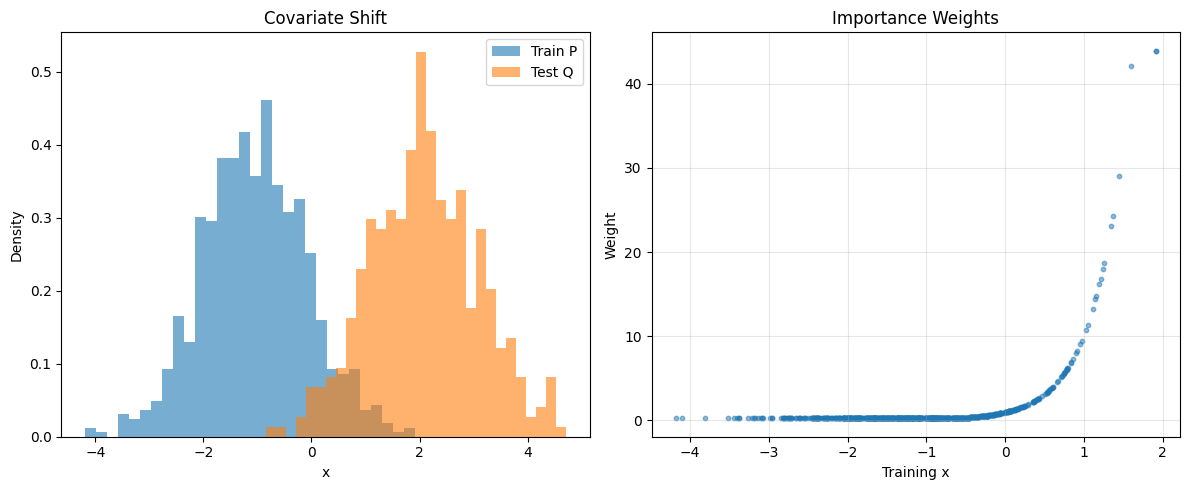

In [14]:
beta_wls = wls(X_train_lr, y_train, weights)
y_pred_wls = X_test_lr @ beta_wls
mse_wls = np.mean((y_pred_wls - y_test)**2)
print(f"WLS 参数: {beta_wls.ravel()}")
print(f"校正前 MSE: {mse_ols:.4f}")
print(f"校正后 MSE: {mse_wls:.4f}")
print(f"MSE 降低: {mse_ols - mse_wls:.4f}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(x_train.ravel(), bins=30, alpha=0.6, label='Train P', density=True)
plt.hist(x_test.ravel(), bins=30, alpha=0.6, label='Test Q', density=True)
plt.xlabel('x'); plt.ylabel('Density'); plt.title('Covariate Shift')
plt.legend()

plt.subplot(1,2,2)
plt.scatter(x_train.ravel(), weights, alpha=0.5, s=10)
plt.xlabel('Training x'); plt.ylabel('Weight'); plt.title('Importance Weights')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 结果说明

- 协变量偏移导致基线 OLS 在测试集上 MSE 较大。
- 通过域分类器估计 P(test|x)，构造重要性权重，加权回归显著降低了测试误差。
- 本实验完整展示了域自适应中的重要性加权方法。